In [10]:
import xarray as xr
import xscen as xs
from xscen import CONFIG
import xclim as xc
import glob
import figanos.matplotlib as fg

xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:108: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.


<Axes: title={'left': 'Annual number of days with daily precipitation\nunder 1 mm/d.'}, xlabel='Time', ylabel='Number of dry days (days)'>

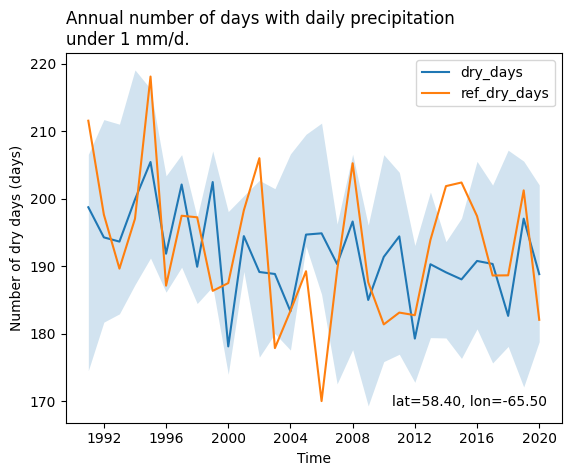

In [21]:
das=[]
for f in glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/ssp245/*/day/pr/*"):
    ds= xr.open_zarr(f)
    ds=ds.sel(time=slice('1991','2020'))
    da=xc.atmos.dry_days(ds.pr, thresh='1 mm/d').to_dataset(name='dry_days')
    da= xs.spatial_mean(da, method='xesmf', spatial_subset=True, kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
    das.append(da)
ens_stats = xs.ensemble_stats(
    datasets=das,
    statistics={
        "ensemble_percentiles": {"split": False}
    }, 
    common_attrs_only=True,
)
ax=fg.timeseries(ens_stats)

# ref
ds_ref=xr.open_zarr(f"{CONFIG['paths']['final']}/reference/QC-E5L_default.zarr.zip")
ds_ref=ds_ref.sel(time=slice('1991','2020'))
ds_ref=xc.atmos.dry_days(ds_ref.pr, thresh='1 mm/d').to_dataset(name='dry_days')

ds_ref= xs.spatial_mean(ds_ref, method='xesmf', spatial_subset=True,kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
fg.timeseries({'ref':ds_ref},ax=ax)
# looks good
# TODO: test with casr when we do it.